# Embeddings comparison exploration
In this document are exploration to the annotated database of gray area triggers


In [ ]:
!pip install -q sentence-transformers
!pip install -q umap-learn
!pip install scikit-bio




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 67.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 00_base.xlsx to 00_base.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel(next(iter(uploaded)))
df.head()



,Law,Article,Spanish text,Relevance,Interpretability,Completeness,Differential Regime,Discretionality,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,Ley 105 de 1958,22,Todas las mercancías o materias primas que ent...,1,3,1,1,1,7,NaN,NaN,NaN
1,Ley 105 de 1958,27,Cuando se introduzcan al país artículos elabor...,1,3,1,1,1,7,NaN,NaN,NaN
2,Ley 47 de 1981,28,De la reexpedición de mercancías. La reexpedic...,1,3,1,1,1,7,NaN,NaN,NaN
3,Ley 47 de 1981,37,De los gravámenes aplicables a insumos y mater...,1,3,1,1,1,7,NaN,NaN,NaN
4,Ley 109 de 1985,34,DE LAS ZONAS FRANCAS DE CARACTER TRANSITORIO. ...,1,3,1,1,1,7,NaN,NaN,NaN


In [ ]:
from sentence_transformers import SentenceTransformer

# Modelo robusto y estándar para embeddings en español
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Embedding de cada artículo
embeddings = model.encode(
    df["Spanish text"].astype(str).tolist(),
    show_progress_bar=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_por_categoria(df, embeddings, categoria, perplexity=30):
    """
    Grafica un t-SNE SOLO para los artículos
    donde la categoría es diferente de cero.
    """

    # Filtrar artículos relevantes para la categoría
    mask = df[categoria] != 0
    emb_cat = embeddings[mask]
    valores = df.loc[mask, categoria]

    # t-SNE a 2D
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca"
    )

    emb_2d = tsne.fit_transform(emb_cat)

    # Gráfico
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=valores,
        cmap="viridis",
        alpha=0.8
    )

    plt.colorbar(scatter, label=f"Valor de {categoria}")
    plt.title(f"t-SNE de artículos donde {categoria} ≠ 0")
    plt.xlabel("Dimensión t-SNE 1")
    plt.ylabel("Dimensión t-SNE 2")

    plt.show()


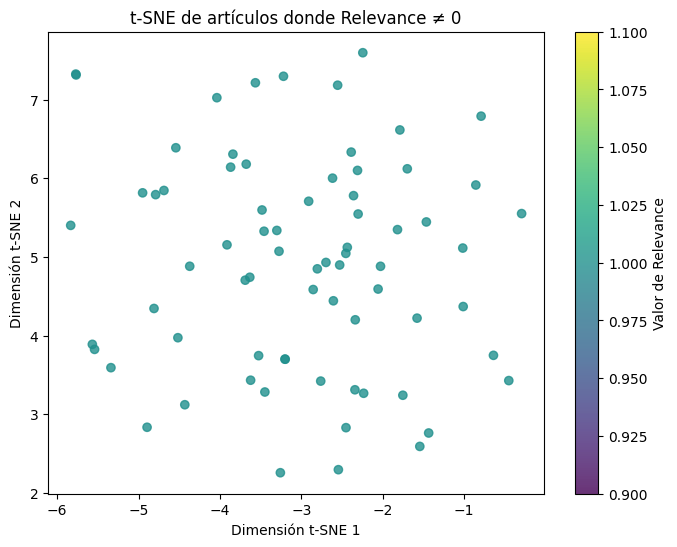

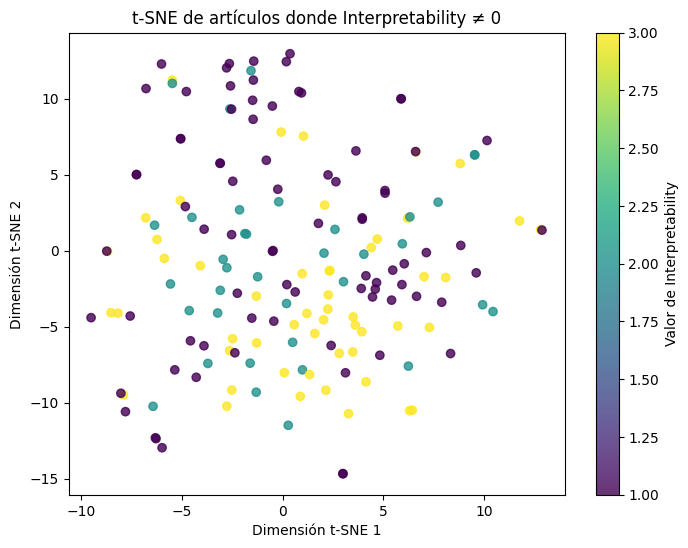

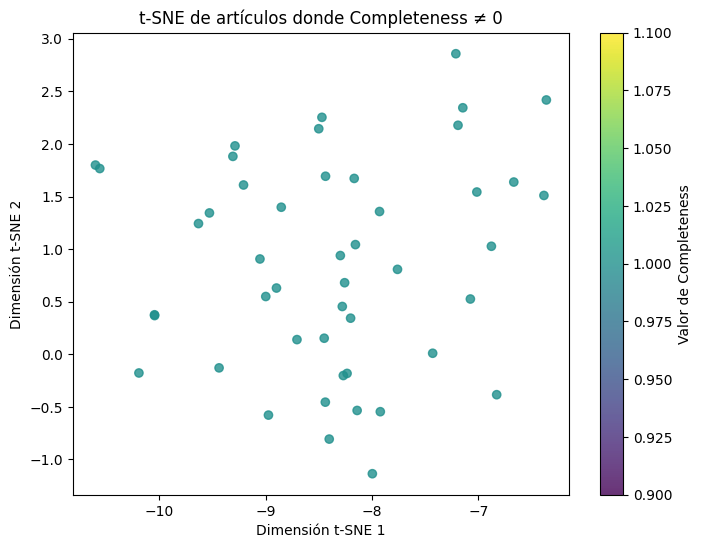

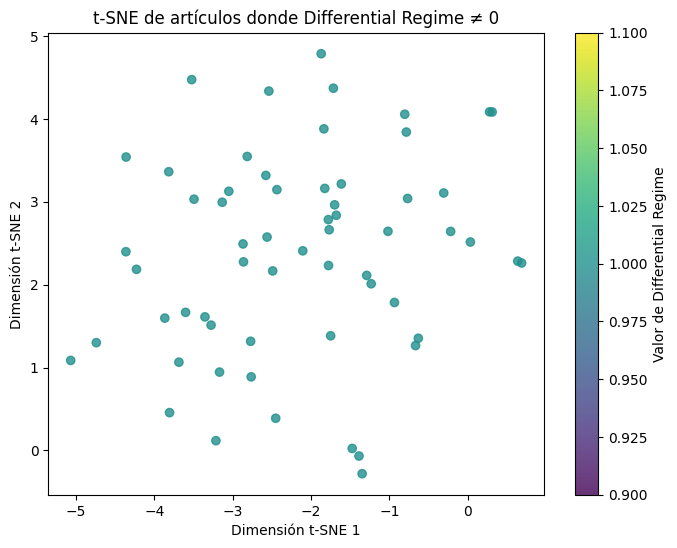

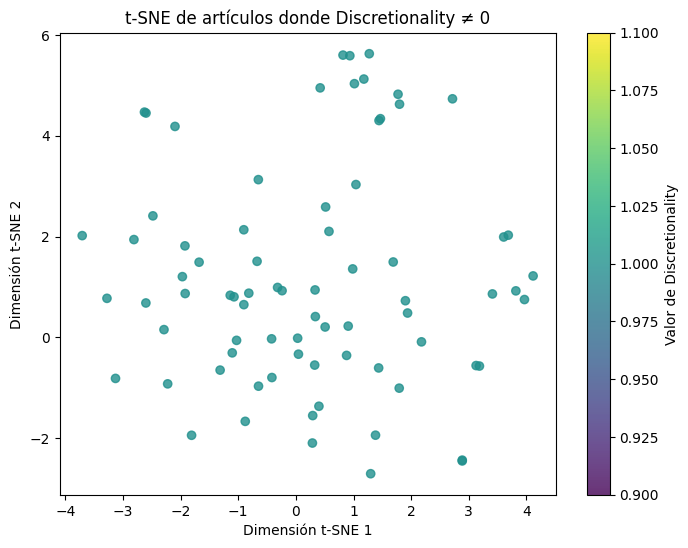

In [ ]:
categorias = [
    "Relevance",
    "Interpretability",
    "Completeness",
    "Differential Regime",
    "Discretionality"
]

for cat in categorias:
    tsne_por_categoria(df, embeddings, cat)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_binario(df, embeddings, categoria, perplexity=30):
    """
    t-SNE global (todos los artículos).
    Colorea según si la categoría aplica (1) o no (0).
    """

    y = df[categoria].astype(int)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca"
    )

    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))

    # No aplica
    plt.scatter(
        emb_2d[y == 0, 0],
        emb_2d[y == 0, 1],
        color="lightgray",
        alpha=0.4,
        label="No aplica"
    )

    # Aplica
    plt.scatter(
        emb_2d[y > 0, 0],
        emb_2d[y > 0, 1],
        color="crimson",
        alpha=0.8,
        label="Aplica"
    )

    plt.title(f"t-SNE — Categoría: {categoria}")
    plt.xlabel("Dimensión t-SNE 1")
    plt.ylabel("Dimensión t-SNE 2")
    plt.legend()
    plt.show()


In [ ]:
def tsne_interpretability(df, embeddings, perplexity=30):
    """
    t-SNE global diferenciando:
    1 = Interpretabilidad alta
    2–3 = Interpretabilidad media / baja
    """

    y = df["Interpretability"].astype(int)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca"
    )

    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))

    # Interpretabilidad = 1
    plt.scatter(
        emb_2d[y == 1, 0],
        emb_2d[y == 1, 1],
        color="seagreen",
        alpha=0.8,
        label="Interpretability = 1"
    )

    # Interpretabilidad = 2 o 3
    plt.scatter(
        emb_2d[y >= 2, 0],
        emb_2d[y >= 2, 1],
        color="darkorange",
        alpha=0.8,
        label="Interpretability = 2–3"
    )

    plt.title("t-SNE — Interpretability (1 vs 2–3)")
    plt.xlabel("Dimensión t-SNE 1")
    plt.ylabel("Dimensión t-SNE 2")
    plt.legend()
    plt.show()


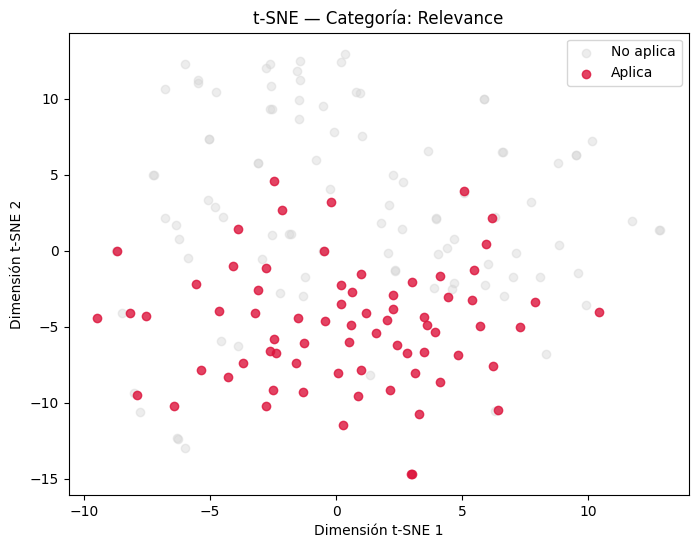

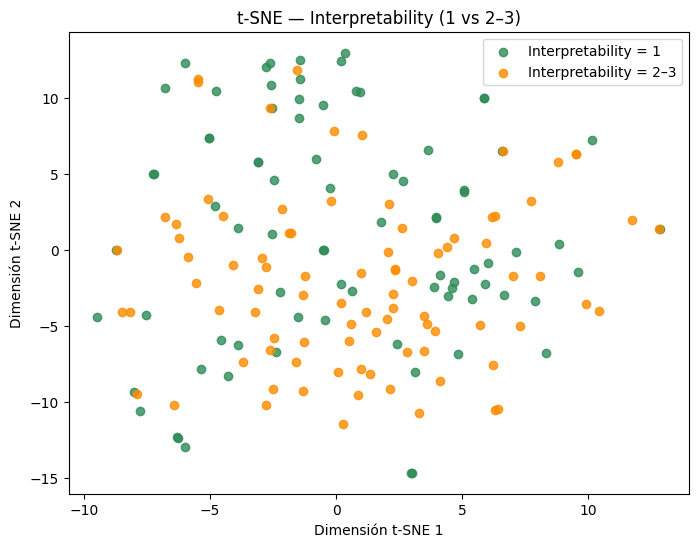

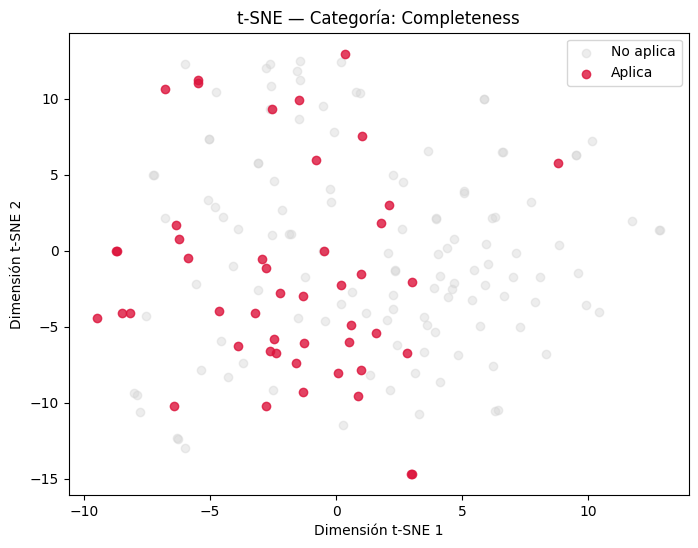

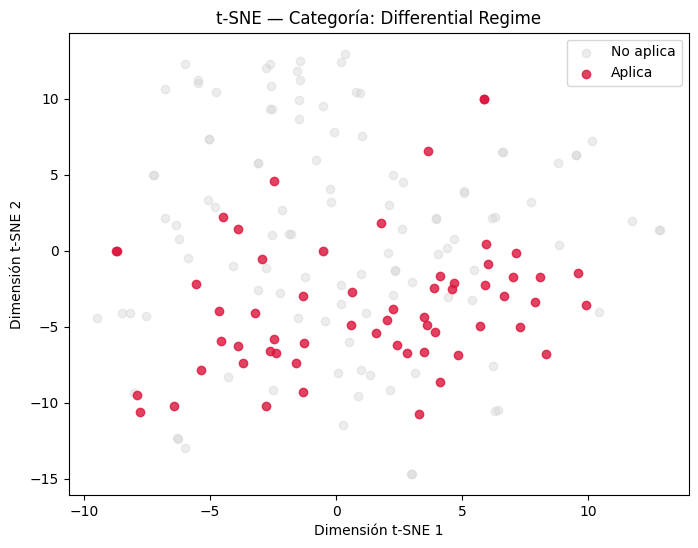

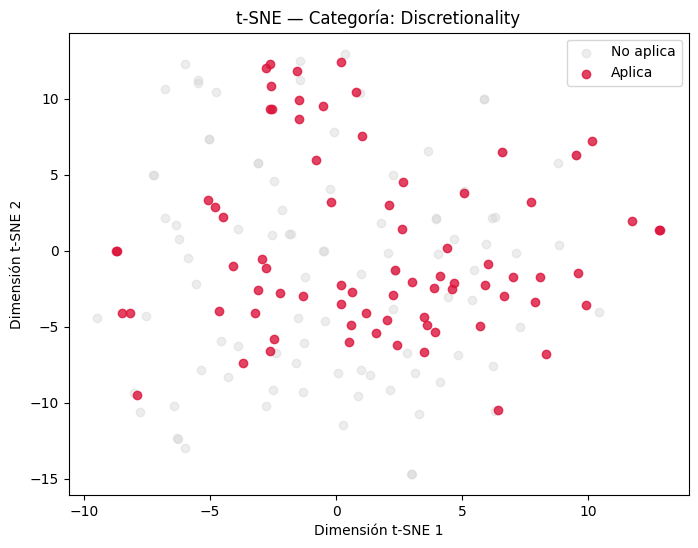

In [ ]:
for cat in categorias:
    if cat == "Interpretability":
        tsne_interpretability(df, embeddings)
    else:
        tsne_binario(df, embeddings, cat)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sns


In [ ]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(embeddings)




/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
def plot_umap_categoria_vs_no(df, X_umap, categoria):
    df_plot = df.copy()

    df_plot["grupo"] = df_plot[categoria].apply(
        lambda x: f"{categoria.capitalize()} ≠ 0" if x != 0 else f"No {categoria.capitalize()}"
    )

    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        hue=df_plot["grupo"],
        alpha=0.6
    )

    plt.title(f"UMAP – {categoria.capitalize()} vs No {categoria.capitalize()}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Grupo")

    plt.tight_layout()
    plt.show()



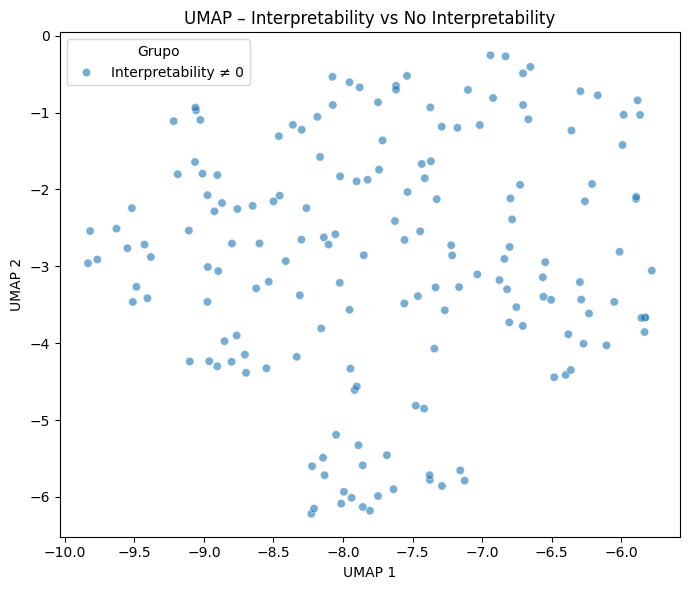

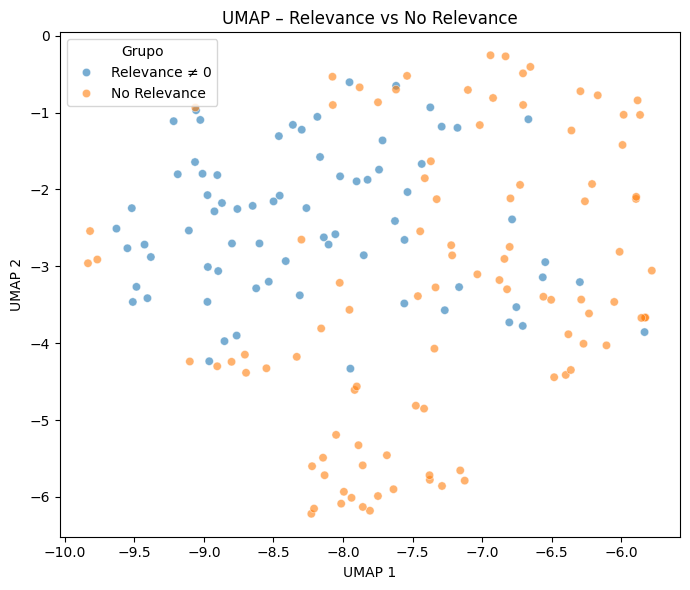

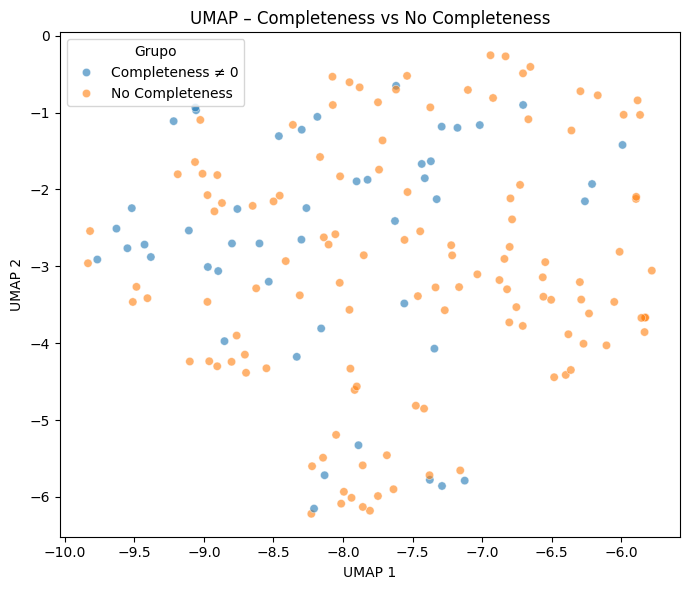

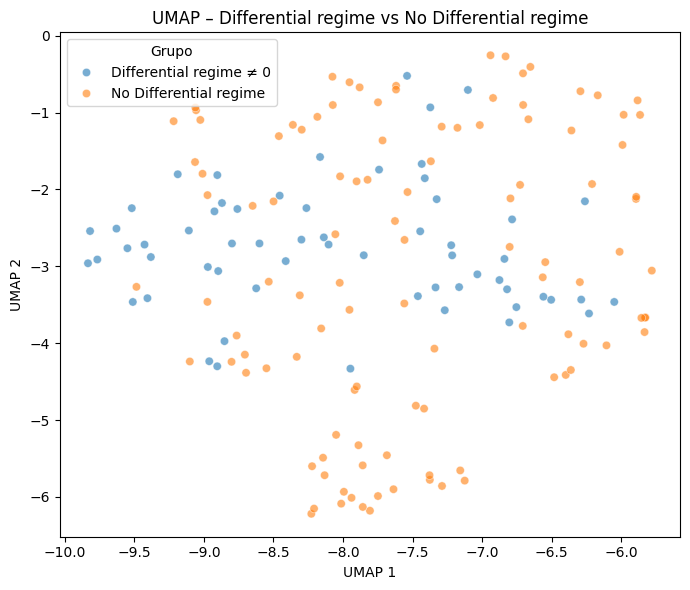

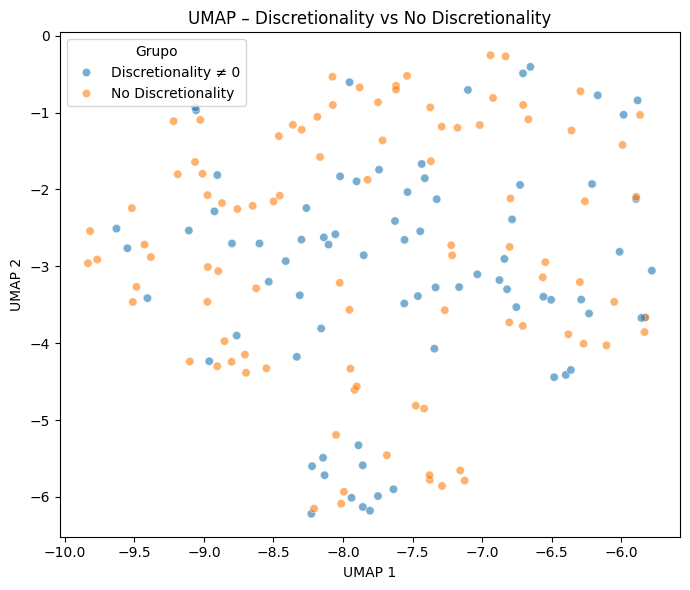

In [ ]:
plot_umap_categoria_vs_no(df, X_umap, "Interpretability")
plot_umap_categoria_vs_no(df, X_umap, "Relevance")
plot_umap_categoria_vs_no(df, X_umap, "Completeness")
plot_umap_categoria_vs_no(df, X_umap, "Differential Regime")
plot_umap_categoria_vs_no(df, X_umap, "Discretionality")

In [ ]:
def plot_scatter(X, df_cat, categoria, metodo="UMAP"):
    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=df_cat["grupo"],
        alpha=0.75
    )

    plt.title(f"{metodo} – {categoria.capitalize()} (artículos con categoría ≠ 0)")
    plt.xlabel(f"{metodo} 1")
    plt.ylabel(f"{metodo} 2")
    plt.legend(title="Grupo")

    plt.tight_layout()
    plt.show()



In [ ]:
def plot_umap_kde_categoria_vs_no(df, X_umap, categoria):
    df_plot = df.copy()

    # Definimos grupos visibles
    if categoria == "Interpretability": # Corrected: Capitalized 'Interpretability'
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: "Interpretability ≠ 0" if x != 0 else "No Interpretability"
        )
    else:
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: f"{categoria.capitalize()} ≠ 0" if x != 0 else f"No {categoria.capitalize()}"
        )

    plt.figure(figsize=(7, 6))

    # KDE por grupo
    for g in df_plot["grupo"].unique():
        idx = df_plot["grupo"] == g
        sns.kdeplot(
            x=X_umap[idx, 0],
            y=X_umap[idx, 1],
            fill=True,
            alpha=0.4,
            label=g
        )

    plt.title(f"KDE en UMAP – {categoria.capitalize()} vs No {categoria.capitalize()}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Grupo")

    plt.tight_layout()
    plt.show()


/tmp/ipython-input-1874876790.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Grupo")


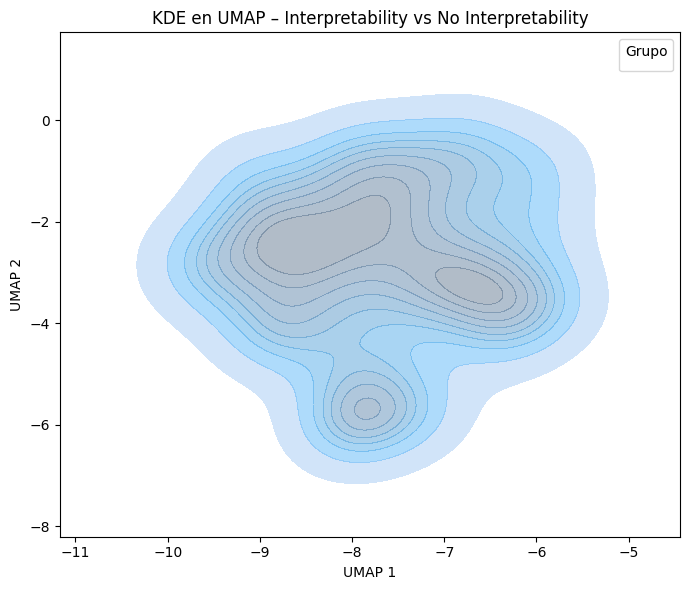

/tmp/ipython-input-1874876790.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Grupo")


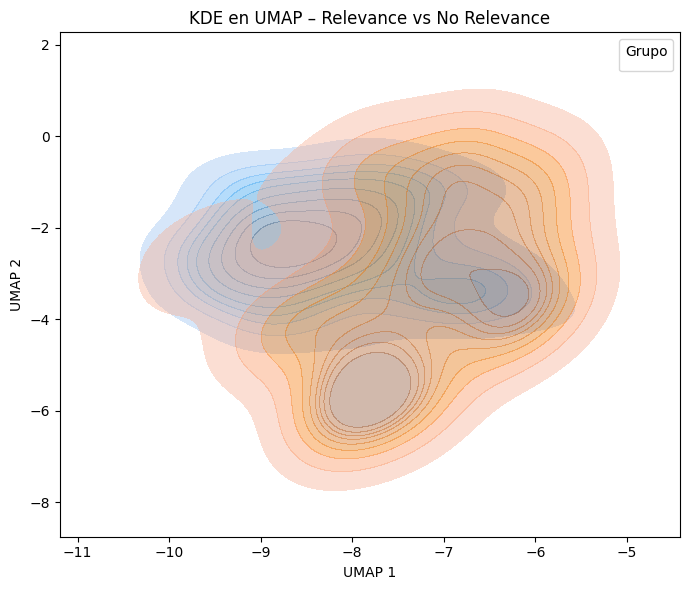

/tmp/ipython-input-1874876790.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Grupo")


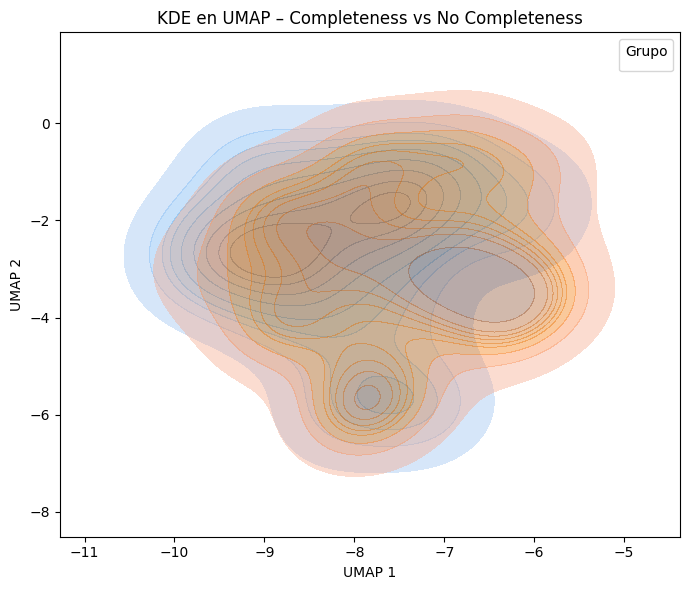

/tmp/ipython-input-1874876790.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Grupo")


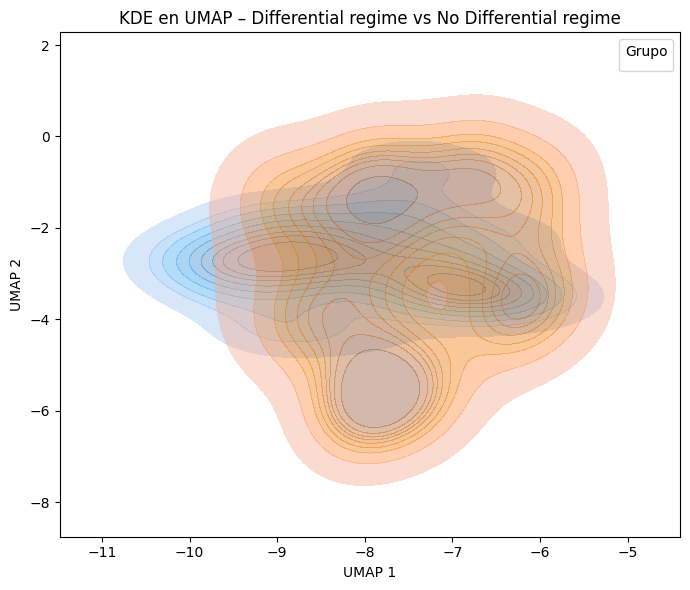

/tmp/ipython-input-1874876790.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Grupo")


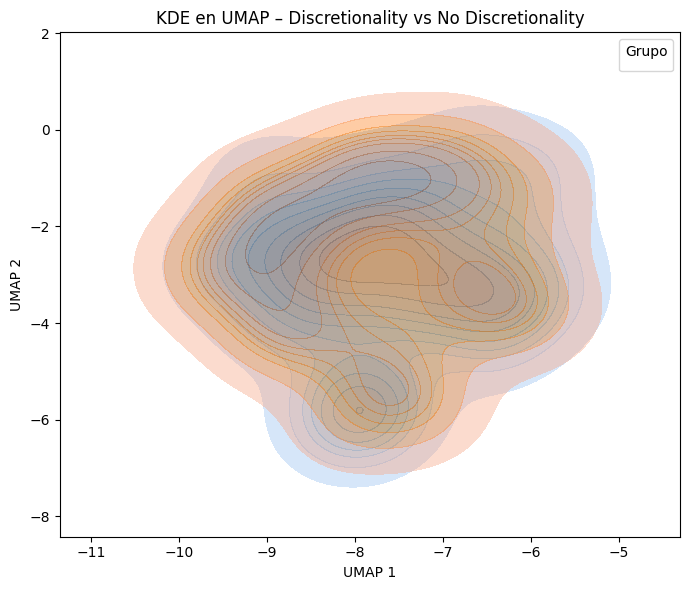

In [ ]:
plot_umap_kde_categoria_vs_no(df, X_umap, "Interpretability")
plot_umap_kde_categoria_vs_no(df, X_umap, "Relevance")
plot_umap_kde_categoria_vs_no(df, X_umap, "Completeness")
plot_umap_kde_categoria_vs_no(df, X_umap, "Differential Regime")
plot_umap_kde_categoria_vs_no(df, X_umap, "Discretionality")

In [ ]:
def plot_umap_hexbin_categoria_vs_no(df, X_umap, categoria):
    df_plot = df.copy()

    # Definir grupos
    if categoria == "Interpretability": # Corrected: Capitalized 'Interpretability'
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: "Interpretability ≠ 0" if x != 0 else "No Interpretability"
        )
    else:
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: f"{categoria.capitalize()} ≠ 0" if x != 0 else f"No {categoria.capitalize()}"
        )

    grupos = df_plot["grupo"].unique()

    fig, axes = plt.subplots(1, len(grupos), figsize=(6 * len(grupos), 5), sharex=True, sharey=True)

    if len(grupos) == 1:
        axes = [axes]

    for ax, g in zip(axes, grupos):
        idx = df_plot["grupo"] == g

        hb = ax.hexbin(
            X_umap[idx, 0],
            X_umap[idx, 1],
            gridsize=30,
            cmap="viridis"
        )

        ax.set_title(g)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2") # Added missing ylabel

    fig.suptitle(f"Hexbin en UMAP – {categoria.capitalize()} vs No {categoria.capitalize()}", fontsize=14) # Added a suptitle for the entire figure
    plt.tight_layout() # Ensure layout is tight
    plt.show()

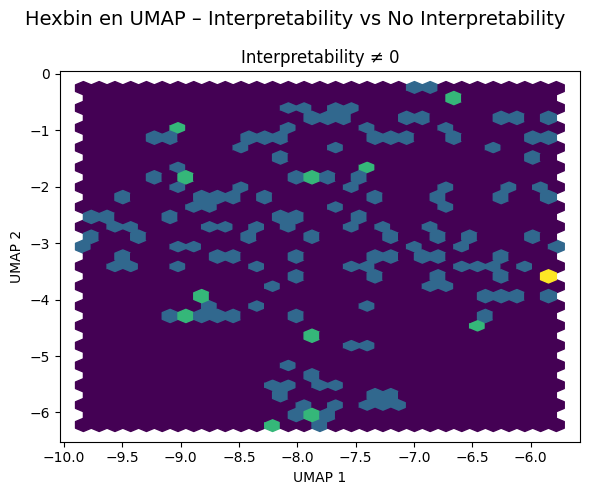

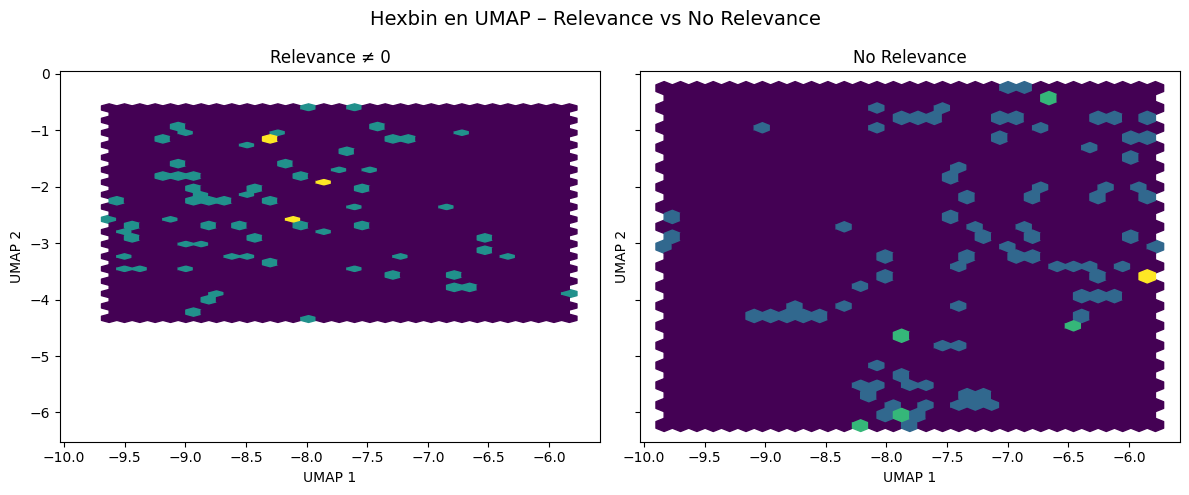

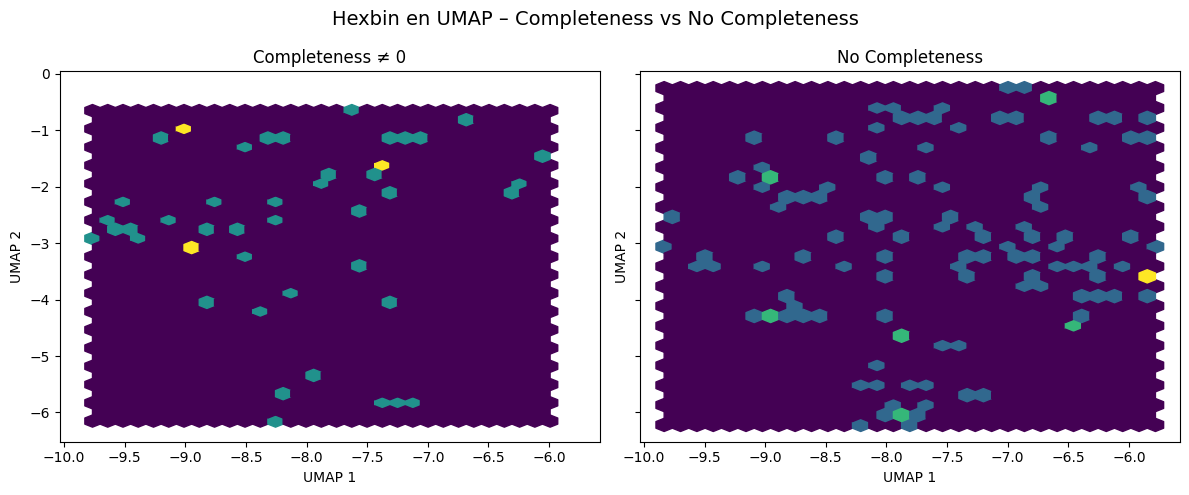

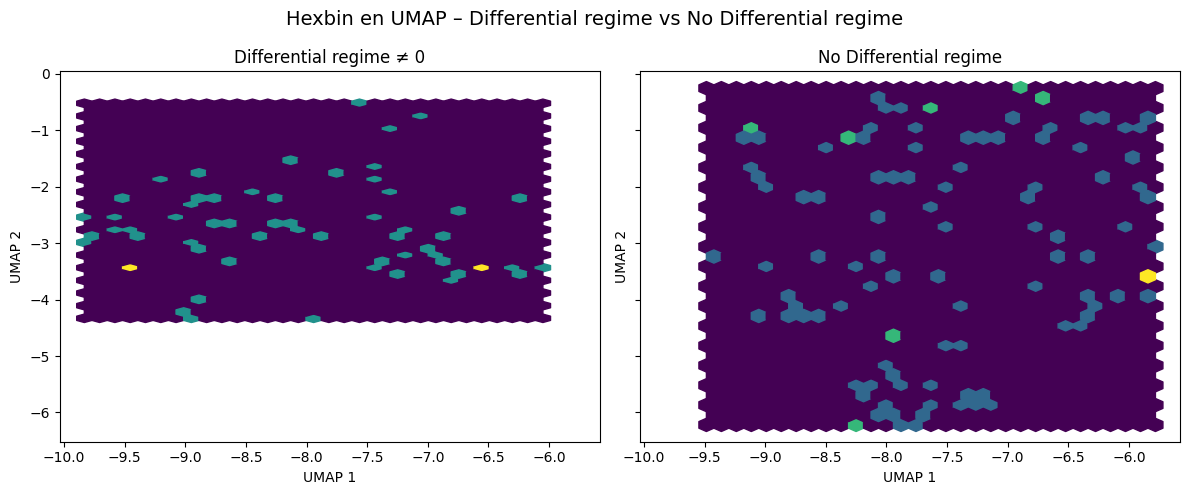

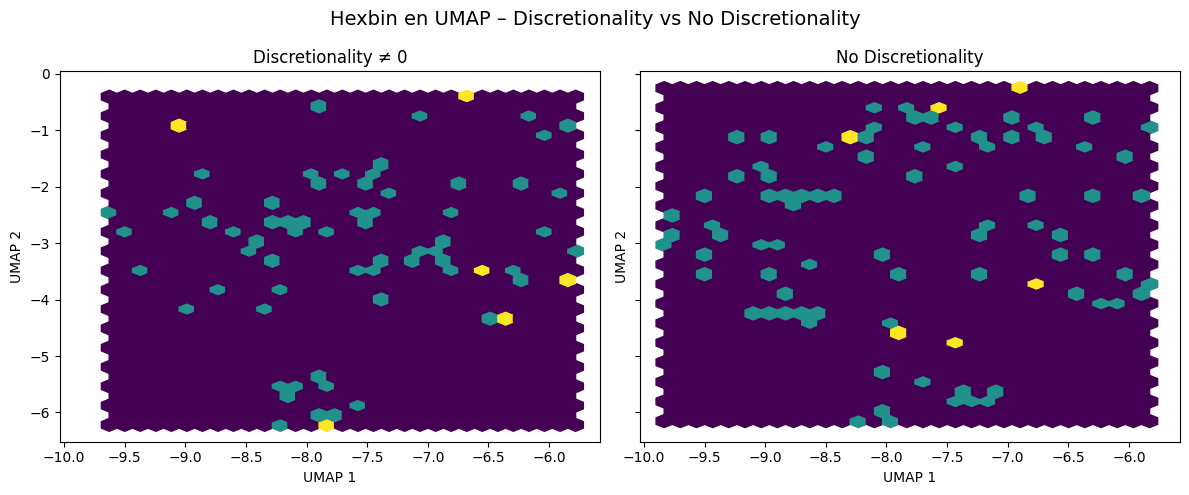

In [ ]:
plot_umap_hexbin_categoria_vs_no(df, X_umap, "Interpretability")
plot_umap_hexbin_categoria_vs_no(df, X_umap, "Relevance")
plot_umap_hexbin_categoria_vs_no(df, X_umap, "Completeness")
plot_umap_hexbin_categoria_vs_no(df, X_umap, "Differential Regime")
plot_umap_hexbin_categoria_vs_no(df, X_umap, "Discretionality")

In [ ]:
def plot_umap_centroides_categoria_vs_no(df, X_umap, categoria):
    df_plot = df.copy()

    # Definir grupos
    if categoria == "Interpretability": # Corrected: Capitalized 'Interpretability'
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: "Interpretability ≠ 0" if x != 0 else "No Interpretability"
        )
    else:
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: f"{categoria.capitalize()} ≠ 0" if x != 0 else f"No {categoria.capitalize()}"
        )

    plt.figure(figsize=(7, 6))

    # Scatter suave de fondo
    sns.scatterplot(
        x=X_umap[:, 0],
        y=X_umap[:, 1],
        hue=df_plot["grupo"],
        alpha=0.25,
        legend=False
    )

    # Calcular y graficar centroides
    for g in df_plot["grupo"].unique():
        idx = df_plot["grupo"] == g
        cx, cy = X_umap[idx].mean(axis=0)
        plt.scatter(
            cx, cy,
            s=220,
            marker="X",
            label=g
        )

    plt.title(f"Centroides en UMAP – {categoria.capitalize()} vs No {categoria.capitalize()}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Grupo")

    plt.tight_layout()
    plt.show()

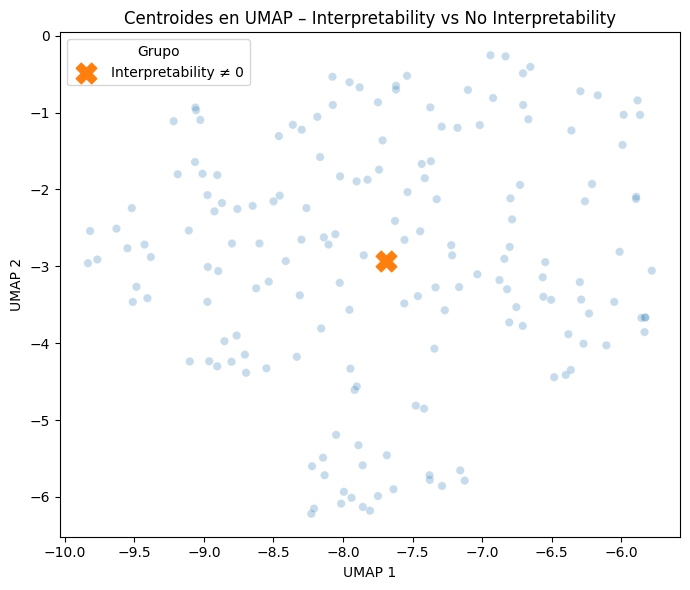

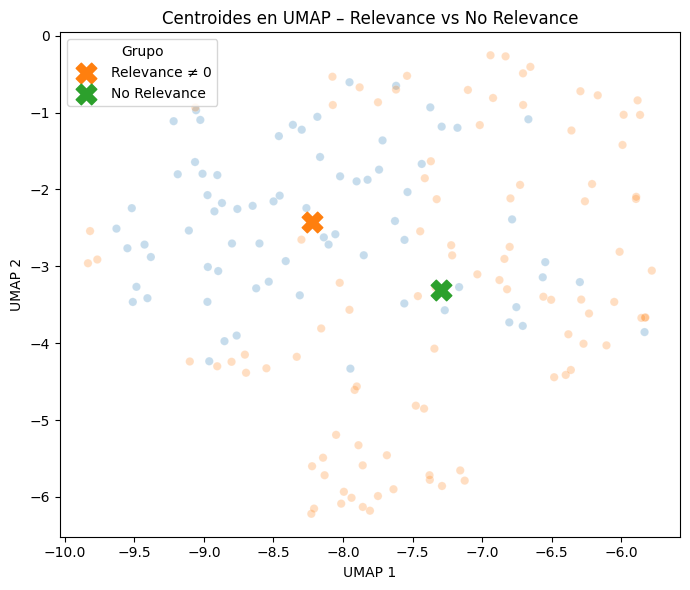

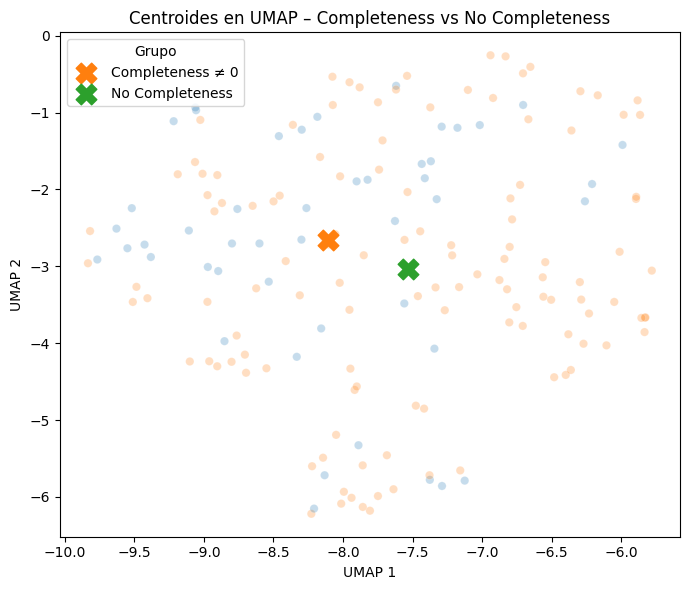

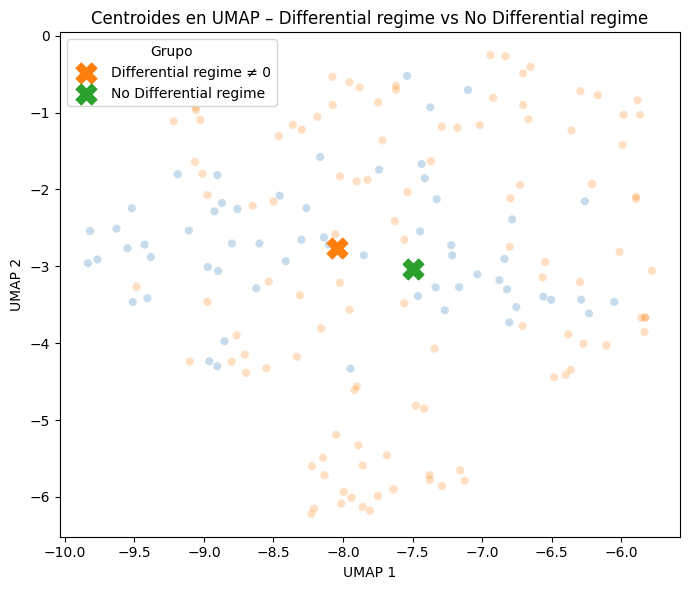

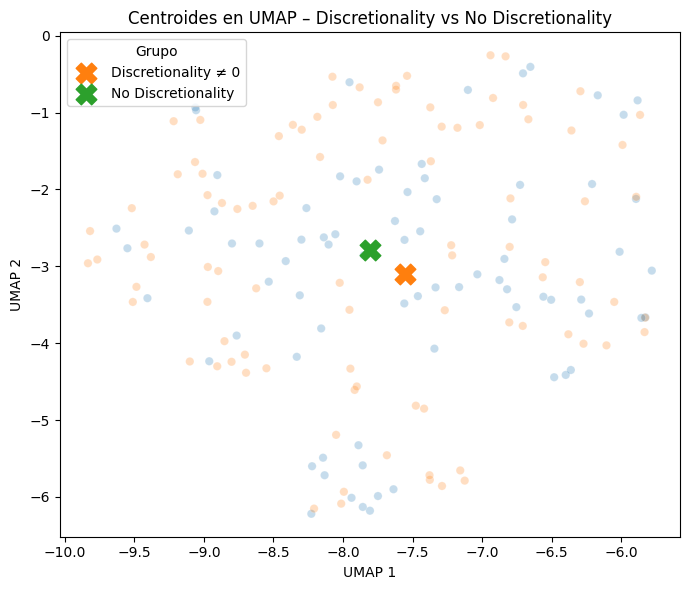

In [ ]:
plot_umap_centroides_categoria_vs_no(df, X_umap, "Interpretability")
plot_umap_centroides_categoria_vs_no(df, X_umap, "Relevance")
plot_umap_centroides_categoria_vs_no(df, X_umap, "Completeness")
plot_umap_centroides_categoria_vs_no(df, X_umap, "Differential Regime")
plot_umap_centroides_categoria_vs_no(df, X_umap, "Discretionality")

In [ ]:
def plot_umap_small_multiples_categoria_vs_no(df, X_umap, categoria):
    df_plot = df.copy()

    # Definir grupos
    if categoria == "Interpretability":
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: "Interpretability ≠ 0" if x != 0 else "No Interpretability"
        )
    else:
        df_plot["grupo"] = df_plot[categoria].apply(
            lambda x: f"{categoria.capitalize()} ≠ 0" if x != 0 else f"No {categoria.capitalize()}"
        )

    grupos = df_plot["grupo"].unique()

    fig, axes = plt.subplots(1, len(grupos), figsize=(6 * len(grupos), 5), sharex=True, sharey=True)

    if len(grupos) == 1:
        axes = [axes]

    for ax, g in zip(axes, grupos):
        idx = df_plot["grupo"] == g

        ax.scatter(
            X_umap[idx, 0],
            X_umap[idx, 1],
            alpha=0.6
        )

        ax.set_title(g)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    fig.suptitle(f"Small multiples – UMAP – {categoria.capitalize()} vs No {categoria.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()

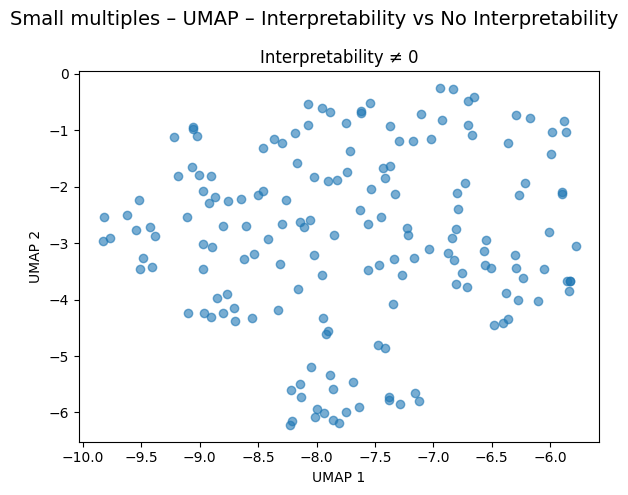

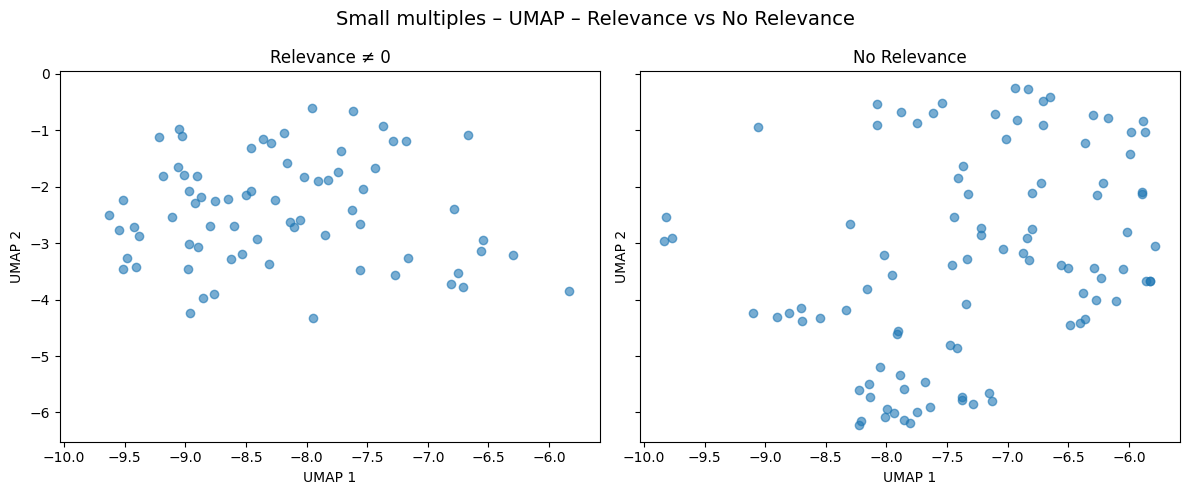

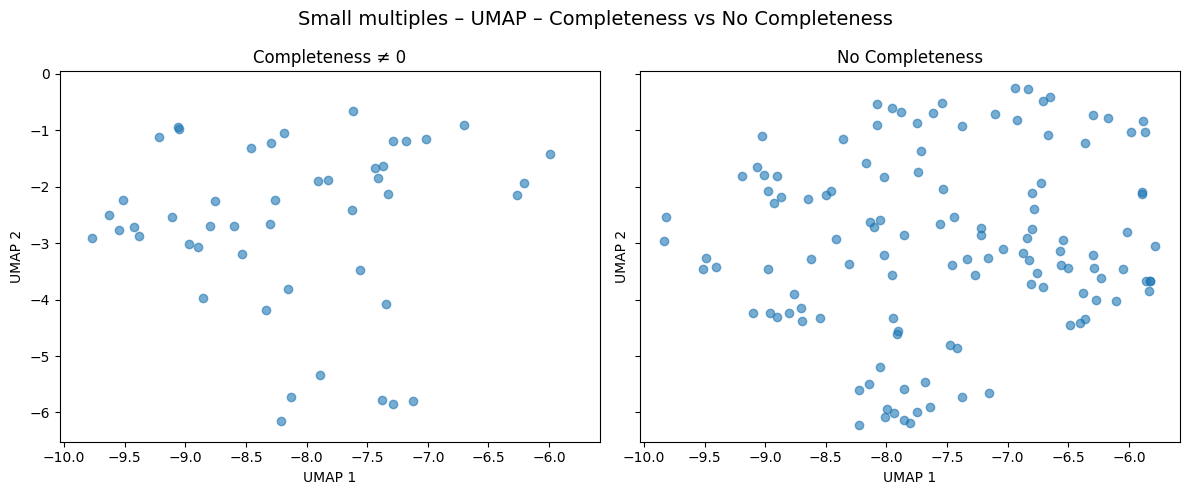

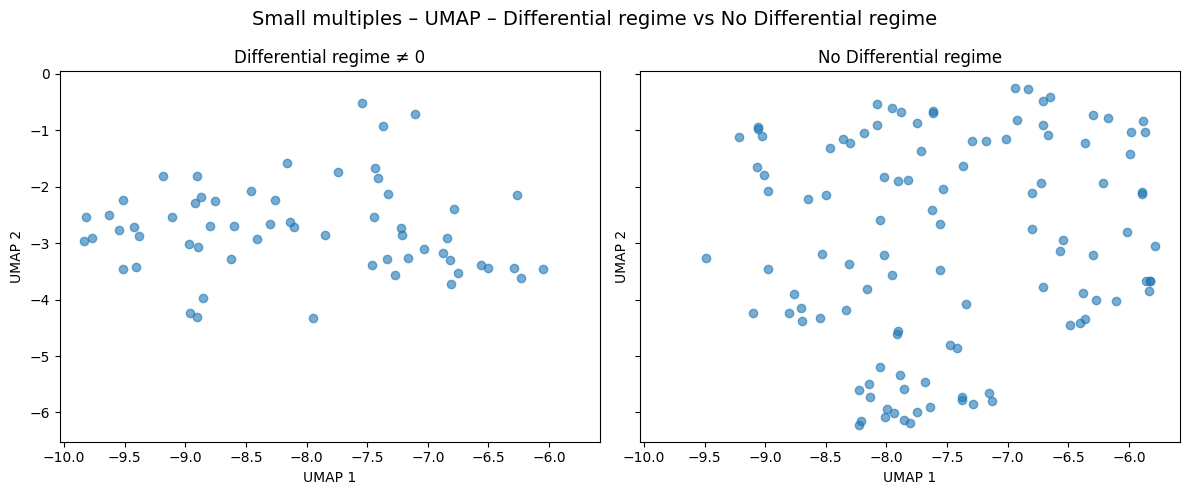

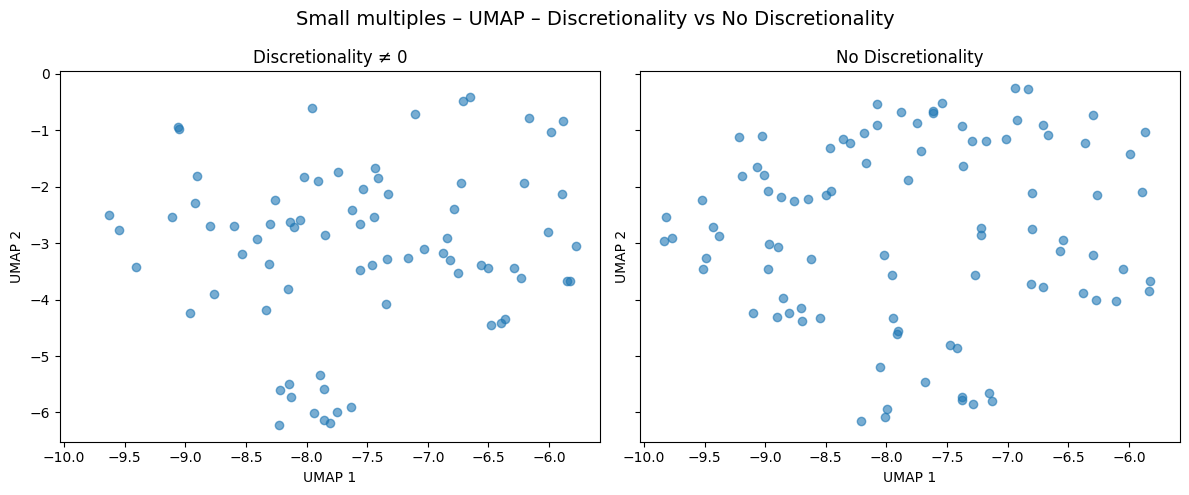

In [ ]:
plot_umap_small_multiples_categoria_vs_no(df, X_umap, "Interpretability")
plot_umap_small_multiples_categoria_vs_no(df, X_umap, "Relevance")
plot_umap_small_multiples_categoria_vs_no(df, X_umap, "Completeness")
plot_umap_small_multiples_categoria_vs_no(df, X_umap, "Differential Regime")
plot_umap_small_multiples_categoria_vs_no(df, X_umap, "Discretionality")

In [ ]:
import numpy as np

def centroid_distance_umap(df, X_umap, categoria):
    if categoria == "interpretability":
        grupo_si = df[categoria] != 0
    else:
        grupo_si = df[categoria] != 0

    grupo_no = df[categoria] == 0

    centroid_si = X_umap[grupo_si].mean(axis=0)
    centroid_no = X_umap[grupo_no].mean(axis=0)

    distancia = np.linalg.norm(centroid_si - centroid_no)

    print(f"Distancia entre centroides ({categoria}): {distancia:.3f}")

    return distancia


In [ ]:
centroid_distance_umap(df, X_umap, "Interpretability")
centroid_distance_umap(df, X_umap, "Relevance")
centroid_distance_umap(df, X_umap, "Completeness")
centroid_distance_umap(df, X_umap, "Differential Regime")
centroid_distance_umap(df, X_umap, "Discretionality")

Distancia entre centroides (Interpretability): nan
Distancia entre centroides (Relevance): 1.272
Distancia entre centroides (Completeness): 0.689
Distancia entre centroides (Differential Regime): 0.611
Distancia entre centroides (Discretionality): 0.398


/tmp/ipython-input-3660056468.py:12: RuntimeWarning: Mean of empty slice.
  centroid_no = X_umap[grupo_no].mean(axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


np.float32(0.3979935)

In [ ]:
import numpy as np

def distancia_centroides_interpretability(df, X_umap):
    grupo_bajo = df["Interpretability"] == 1
    grupo_alto = df["Interpretability"].isin([2, 3])

    centroid_bajo = X_umap[grupo_bajo].mean(axis=0)
    centroid_alto = X_umap[grupo_alto].mean(axis=0)

    distancia = np.linalg.norm(centroid_bajo - centroid_alto)
    return distancia

In [ ]:
dist_interp = distancia_centroides_interpretability(df, X_umap)
print(f"Distancia entre centroides (Interpretability): {dist_interp:.3f}")


Distancia entre centroides (Interpretability): 0.860


In [ ]:
from skbio.stats.distance import DistanceMatrix
from skbio.stats.distance import permanova
from scipy.spatial.distance import pdist, squareform


In [ ]:
import pandas as pd
from skbio.stats.distance import DistanceMatrix
from skbio.stats.distance import permanova
from scipy.spatial.distance import pdist, squareform

def permanova_umap(df, X_umap, categoria):
    # The 'categoria' variable will now correctly be capitalized due to previous fixes.
    grupos = df[categoria].apply(lambda x: "si" if x != 0 else "no")

    # Check if there are at least two unique groups
    if grupos.nunique() < 2:
        print(f"\nPERMANOVA – {categoria}: Skipping, only one group found ({grupos.iloc[0]}).")
        return None

    # Distancias entre puntos
    distancias = squareform(pdist(X_umap, metric="euclidean"))

    # Create DistanceMatrix with IDs from the DataFrame index to match 'grupos'
    dm = DistanceMatrix(distancias, ids=df.index)

    resultado = permanova(
        distance_matrix=dm,
        grouping=grupos,
        permutations=999
    )

    print(f"\nPERMANOVA – {categoria}")
    print(resultado)

    return resultado

In [ ]:
permanova_umap(df, X_umap, "Interpretability")
permanova_umap(df, X_umap, "Relevance")
permanova_umap(df, X_umap, "Completeness")
permanova_umap(df, X_umap, "Differential Regime")
permanova_umap(df, X_umap, "Discretionality")


PERMANOVA – Interpretability: Skipping, only one group found (si).

PERMANOVA – Relevance
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     169
number of groups                  2
test statistic             21.22746
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA – Completeness
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     169
number of groups                  2
test statistic             4.665281
p-value                       0.014
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA – Differential Regime
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     169
number of groups                  2
test statistic             4.174033
p-value                       0.022
number of permutations          999
Name: PERMANOVA 

,PERMANOVA results
method name,PERMANOVA
test statistic name,pseudo-F
sample size,169
number of groups,2
test statistic,1.886474
p-value,0.153
number of permutations,999


In [ ]:
df["interpretability_bin"] = df["Interpretability"].apply(
    lambda x: 0 if x == 1 else 1
)
df["interpretability_bin"].value_counts()
# matriz de distancias sobre el embedding UMAP
dist_matrix = squareform(pdist(X_umap, metric="euclidean"))
dm = DistanceMatrix(dist_matrix, ids=df.index)

# PERMANOVA
permanova_results = permanova(
    dm,
    df["interpretability_bin"],
    permutations=999
)

permanova_results

,PERMANOVA results
method name,PERMANOVA
test statistic name,pseudo-F
sample size,169
number of groups,2
test statistic,9.275201
p-value,0.001
number of permutations,999


Grupo_Normativo
1    139
0     30
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


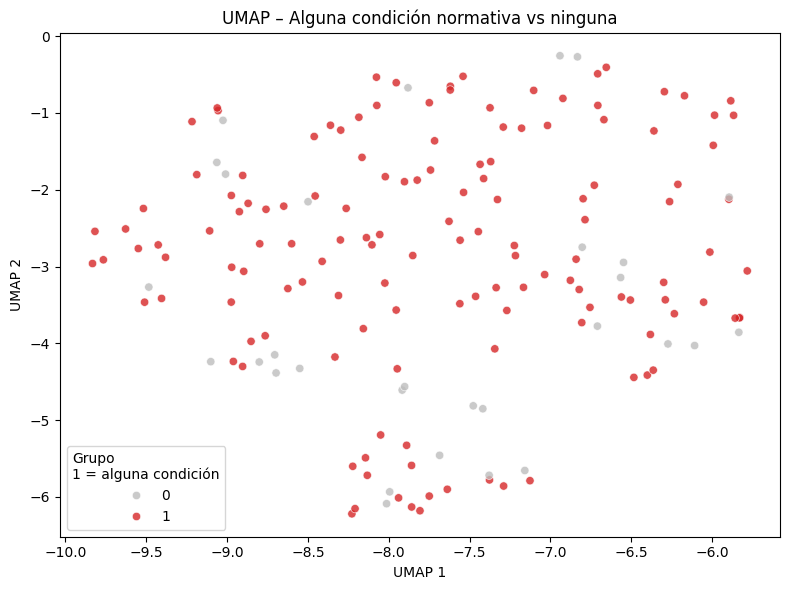

/tmp/ipython-input-2020100808.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


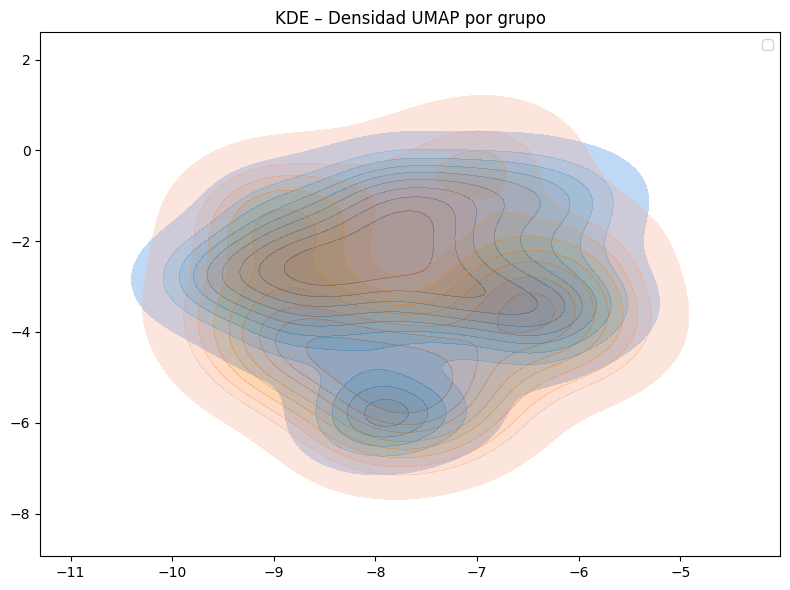

Distancia entre centroides: 0.763

PERMANOVA – Alguna condición normativa vs ninguna
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     169
number of groups                  2
test statistic             4.147926
p-value                       0.032
number of permutations          999
Name: PERMANOVA results, dtype: object


In [ ]:
# ==============================
# 1. Librerías
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# ==============================
# 2. Construcción del grupo lógico (OR)
# ==============================
df["Grupo_Normativo"] = (
    (df["Interpretability"] != 1) |
    (df["Completeness"] != 0) |
    (df["Differential Regime"] != 0) | # Corrected column name here
    (df["Discretionality"] != 0)
).astype(int)

# Verificar tamaños
print(df["Grupo_Normativo"].value_counts())

# ==============================
# 3. UMAP
# ==============================
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(embeddings)

# ==============================
# 4. Gráfico UMAP
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df["Grupo_Normativo"],
    palette={1: "#d62728", 0: "#bdbdbd"},
    alpha=0.8
)

plt.title("UMAP – Alguna condición normativa vs ninguna")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Grupo\n1 = alguna condición")
plt.tight_layout()
plt.show()

# ==============================
# 5. KDE
# ==============================
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=X_umap[df["Grupo_Normativo"]==1,0],
    y=X_umap[df["Grupo_Normativo"]==1,1],
    fill=True,
    alpha=0.6,
    label="Alguna condición normativa"
)

sns.kdeplot(
    x=X_umap[df["Grupo_Normativo"]==0,0],
    y=X_umap[df["Grupo_Normativo"]==0,1],
    fill=True,
    alpha=0.3,
    label="Ninguna condición"
)

plt.title("KDE – Densidad UMAP por grupo")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 6. Distancia entre centroides
# ==============================
centro_si = X_umap[df["Grupo_Normativo"]==1].mean(axis=0)
centro_no = X_umap[df["Grupo_Normativo"]==0].mean(axis=0)

dist_centroides = np.linalg.norm(centro_si - centro_no)
print(f"Distancia entre centroides: {dist_centroides:.3f}")

# ==============================
# 7. PERMANOVA
# ==============================
dist_matrix = squareform(pdist(X_umap, metric="euclidean"))
dm = DistanceMatrix(dist_matrix, ids=df.index)

permanova_res = permanova(
    dm,
    df["Grupo_Normativo"],
    permutations=999
)

print("\nPERMANOVA – Alguna condición normativa vs ninguna")
print(permanova_res)

grupo_normativo
0    160
1      9
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


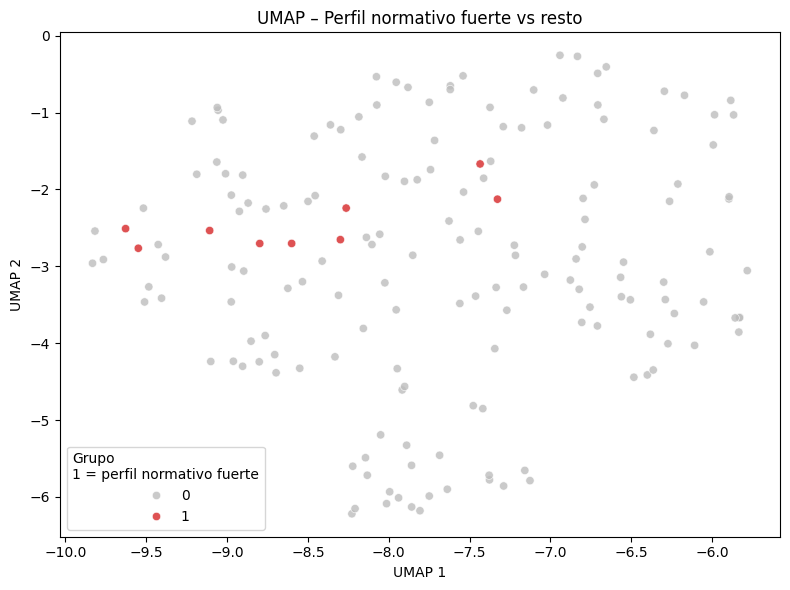

/tmp/ipython-input-1338692623.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


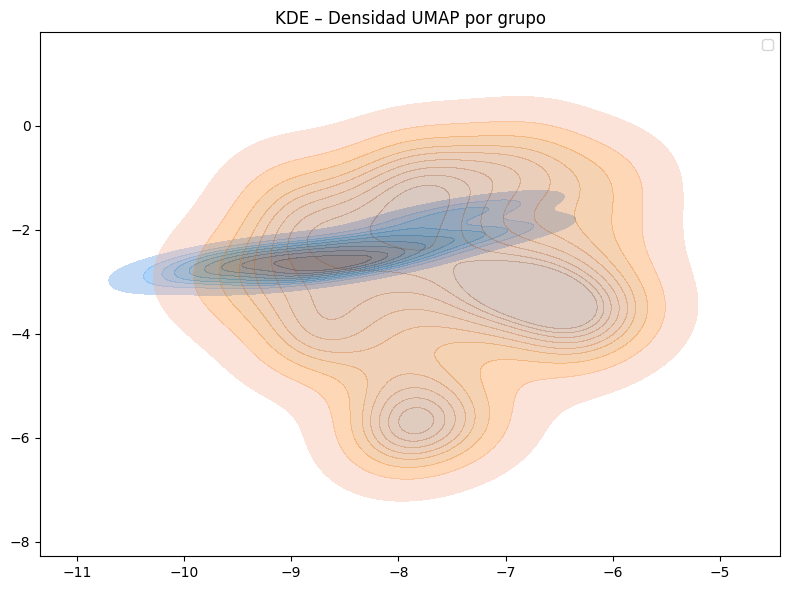

Distancia entre centroides: 1.054

PERMANOVA – Perfil normativo fuerte vs resto
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     169
number of groups                  2
test statistic             2.707408
p-value                       0.063
number of permutations          999
Name: PERMANOVA results, dtype: object


In [ ]:
# ==============================
# 1. Librerías
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# ==============================
# 2. Construcción del grupo lógico
# ==============================
df["grupo_normativo"] = (
    (df["Interpretability"] != 1) & # Corrected: Capitalized 'Interpretability'
    (df["Completeness"] == 1) &   # Corrected: Capitalized 'Completeness'
    (df["Differential Regime"] == 1) & # Corrected: Capitalized 'Differential Regime'
    (df["Discretionality"] == 1)    # Corrected: Capitalized 'Discretionality'
).astype(int)

# Ver cuántos hay en cada grupo
print(df["grupo_normativo"].value_counts())

# ==============================
# 3. UMAP
# ==============================
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(embeddings)

# ==============================
# 4. Gráfico UMAP
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df["grupo_normativo"],
    palette={1: "#d62728", 0: "#bdbdbd"},
    alpha=0.8
)

plt.title("UMAP – Perfil normativo fuerte vs resto")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Grupo\n1 = perfil normativo fuerte")
plt.tight_layout()
plt.show()

# ==============================
# 5. KDE (densidad)
# ==============================
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=X_umap[df["grupo_normativo"]==1,0],
    y=X_umap[df["grupo_normativo"]==1,1],
    fill=True,
    alpha=0.6,
    label="Perfil normativo fuerte"
)

sns.kdeplot(
    x=X_umap[df["grupo_normativo"]==0,0],
    y=X_umap[df["grupo_normativo"]==0,1],
    fill=True,
    alpha=0.3,
    label="Resto"
)

plt.title("KDE – Densidad UMAP por grupo")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 6. Distancia entre centroides
# ==============================
centro_fuerte = X_umap[df["grupo_normativo"]==1].mean(axis=0)
centro_resto  = X_umap[df["grupo_normativo"]==0].mean(axis=0)

dist_centroides = np.linalg.norm(centro_fuerte - centro_resto)
print(f"Distancia entre centroides: {dist_centroides:.3f}")

# ==============================
# 7. PERMANOVA
# ==============================
dist_matrix = squareform(pdist(X_umap, metric="euclidean"))
dm = DistanceMatrix(dist_matrix, ids=df.index) # Corrected: Added ids=df.index

permanova_res = permanova(
    dm,
    df["grupo_normativo"],
    permutations=999
)

print("\nPERMANOVA – Perfil normativo fuerte vs resto")
print(permanova_res)


Score_Normativo
1    30
2    41
3    43
4    30
5    19
6     6
Name: count, dtype: int64
Grupo_Normativo
0    144
1     25
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


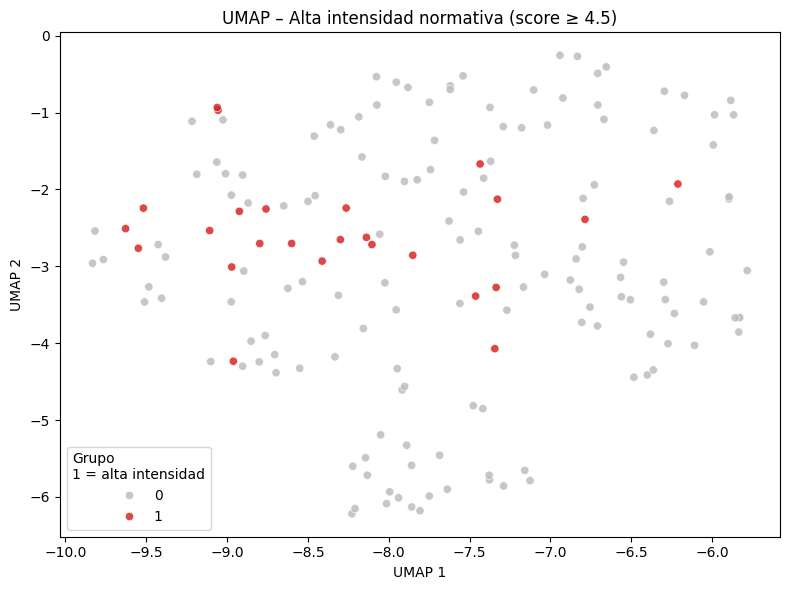

/tmp/ipython-input-4109737977.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


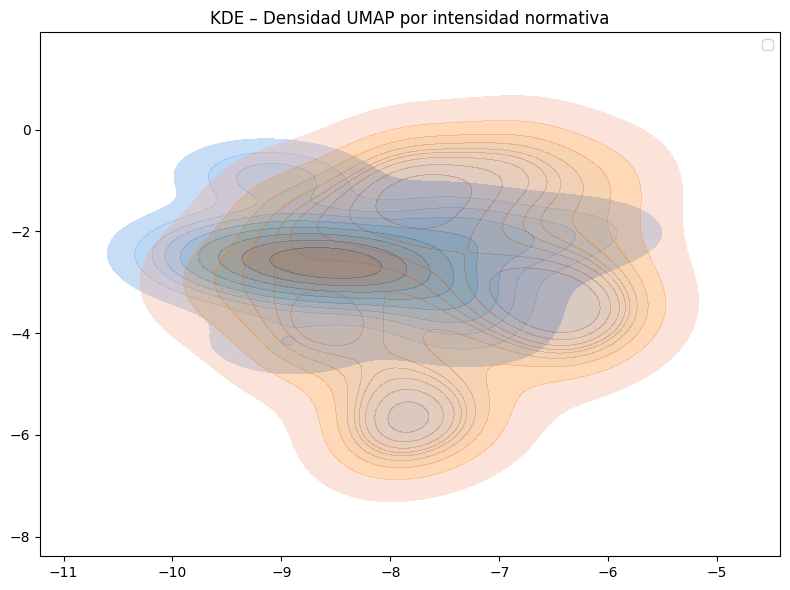

Distancia entre centroides: 0.852

PERMANOVA – Alta intensidad normativa vs resto
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     169
number of groups                  2
test statistic             4.473114
p-value                       0.021
number of permutations          999
Name: PERMANOVA results, dtype: object


In [ ]:
# ==============================
# 1. Construcción del score normativo
# ==============================
df["Score_Normativo"] = (
    df["Interpretability"]  +
    df["Completeness"] +
    df["Differential Regime"] + # Corrected column name here
    df["Discretionality"]
)

# ==============================
# 2. Definición de grupos
#    (alta intensidad normativa)
# ==============================
df["Grupo_Normativo"] = (df["Score_Normativo"] >= 4.5).astype(int)

# Revisar distribución
print(df["Score_Normativo"].value_counts().sort_index())
print(df["Grupo_Normativo"].value_counts())

# ==============================
# 3. UMAP
# ==============================
import umap
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(embeddings)

# ==============================
# 4. UMAP plot
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df["Grupo_Normativo"],
    palette={1: "#d62728", 0: "#bdbdbd"},
    alpha=0.85
)

plt.title("UMAP – Alta intensidad normativa (score ≥ 4.5)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Grupo\n1 = alta intensidad")
plt.tight_layout()
plt.show()

# ==============================
# 5. KDE
# ==============================
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=X_umap[df["Grupo_Normativo"]==1,0],
    y=X_umap[df["Grupo_Normativo"]==1,1],
    fill=True,
    alpha=0.6,
    label="Alta intensidad normativa"
)

sns.kdeplot(
    x=X_umap[df["Grupo_Normativo"]==0,0],
    y=X_umap[df["Grupo_Normativo"]==0,1],
    fill=True,
    alpha=0.3,
    label="Baja / nula intensidad"
)

plt.title("KDE – Densidad UMAP por intensidad normativa")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 6. Distancia entre centroides
# ==============================
import numpy as np

centro_alta = X_umap[df["Grupo_Normativo"]==1].mean(axis=0)
centro_baja = X_umap[df["Grupo_Normativo"]==0].mean(axis=0)

dist_centroides = np.linalg.norm(centro_alta - centro_baja)
print(f"Distancia entre centroides: {dist_centroides:.3f}")

# ==============================
# 7. PERMANOVA
# ==============================
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

dist_matrix = squareform(pdist(X_umap, metric="euclidean"))
dm = DistanceMatrix(dist_matrix, ids=df.index) # Added ids=df.index

permanova_res = permanova(
    dm,
    df["Grupo_Normativo"],
    permutations=999
)

print("\nPERMANOVA – Alta intensidad normativa vs resto")
print(permanova_res)

In [ ]:
print(df["Score_Normativo"].value_counts().sort_index())

In [35]:
!jupyter nbconvert --to pdf notebook.ipynb

[NbConvertApp] WARNING | pattern 'notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Ex